# 01 — Data Quality Audit
## Decision Intelligence System · Olist E-Commerce Dataset

**Objective:** Before any analysis, we systematically inspect all 9 dataset tables for:
- Shape and data types
- Missing values (nulls)
- Duplicate records
- Date format issues
- Inconsistent values
- Outliers in key numeric columns

**Output:** A clean master dataframe ready for EDA in notebook 02.

---

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

print('Libraries loaded successfully!')

Libraries loaded successfully!


## 2. Load All 9 Datasets

In [2]:
# -------------------------------------------------------
# Set the path to your /data folder
# If your data folder is in the same directory as this notebook:
DATA_PATH = '../data/'
# -------------------------------------------------------

df_orders       = pd.read_csv(DATA_PATH + 'olist_orders_dataset.csv')
df_items        = pd.read_csv(DATA_PATH + 'olist_order_items_dataset.csv')
df_customers    = pd.read_csv(DATA_PATH + 'olist_customers_dataset.csv')
df_products     = pd.read_csv(DATA_PATH + 'olist_products_dataset.csv')
df_sellers      = pd.read_csv(DATA_PATH + 'olist_sellers_dataset.csv')
df_reviews      = pd.read_csv(DATA_PATH + 'olist_order_reviews_dataset.csv')
df_payments     = pd.read_csv(DATA_PATH + 'olist_order_payments_dataset.csv')
df_geolocation  = pd.read_csv(DATA_PATH + 'olist_geolocation_dataset.csv')
df_translation  = pd.read_csv(DATA_PATH + 'product_category_name_translation.csv')

datasets = {
    'orders'      : df_orders,
    'items'       : df_items,
    'customers'   : df_customers,
    'products'    : df_products,
    'sellers'     : df_sellers,
    'reviews'     : df_reviews,
    'payments'    : df_payments,
    'geolocation' : df_geolocation,
    'translation' : df_translation
}

print('All 9 datasets loaded!')
print(f"{'Dataset':<15} {'Rows':>8} {'Columns':>8}")
print('-' * 35)
for name, df in datasets.items():
    print(f"{name:<15} {df.shape[0]:>8,} {df.shape[1]:>8}")

All 9 datasets loaded!
Dataset             Rows  Columns
-----------------------------------
orders            99,441        8
items            112,650        7
customers         99,441        5
products          32,951        9
sellers            3,095        4
reviews           99,224        7
payments         103,886        5
geolocation     1,000,163        5
translation           71        2


## 3. Full Data Quality Report — All Tables

We build a summary function that runs across every table and reports shape, nulls, and duplicates in one shot.

In [3]:
def data_quality_report(name, df):
    print('=' * 60)
    print(f'  TABLE: {name.upper()}')
    print('=' * 60)
    print(f'  Shape : {df.shape[0]:,} rows × {df.shape[1]} columns')
    print(f'  Duplicates: {df.duplicated().sum():,}')
    print()

    # Null summary
    null_counts = df.isnull().sum()
    null_pct    = (null_counts / len(df) * 100).round(2)
    dtypes      = df.dtypes

    report = pd.DataFrame({
        'dtype'     : dtypes,
        'null_count': null_counts,
        'null_%'    : null_pct
    })
    print(report.to_string())
    print()

for name, df in datasets.items():
    data_quality_report(name, df)

  TABLE: ORDERS
  Shape : 99,441 rows × 8 columns
  Duplicates: 0

                              dtype  null_count  null_%
order_id                        str           0    0.00
customer_id                     str           0    0.00
order_status                    str           0    0.00
order_purchase_timestamp        str           0    0.00
order_approved_at               str         160    0.16
order_delivered_carrier_date    str        1783    1.79
order_delivered_customer_date   str        2965    2.98
order_estimated_delivery_date   str           0    0.00

  TABLE: ITEMS
  Shape : 112,650 rows × 7 columns
  Duplicates: 0

                       dtype  null_count  null_%
order_id                 str           0    0.00
order_item_id          int64           0    0.00
product_id               str           0    0.00
seller_id                str           0    0.00
shipping_limit_date      str           0    0.00
price                float64           0    0.00
freight_value     

## 4. Deep Dive — Orders Table

The orders table is the **core** of this dataset. We inspect it closely.

In [4]:
print('Orders table — first 5 rows:')
df_orders.head()

Orders table — first 5 rows:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [5]:
# Order status distribution
print('Order Status Breakdown:')
status_counts = df_orders['order_status'].value_counts()
status_pct    = (status_counts / len(df_orders) * 100).round(2)

status_df = pd.DataFrame({'count': status_counts, '%': status_pct})
print(status_df.to_string())

Order Status Breakdown:
              count     %
order_status             
delivered     96478 97.02
shipped        1107  1.11
canceled        625  0.63
unavailable     609  0.61
invoiced        314  0.32
processing      301  0.30
created           5  0.01
approved          2  0.00


In [6]:
# Convert all timestamp columns to datetime
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    df_orders[col] = pd.to_datetime(df_orders[col])

print('Date range in the dataset:')
print(f"  Earliest order : {df_orders['order_purchase_timestamp'].min()}")
print(f"  Latest order   : {df_orders['order_purchase_timestamp'].max()}")
print(f"  Total span     : {(df_orders['order_purchase_timestamp'].max() - df_orders['order_purchase_timestamp'].min()).days} days")

Date range in the dataset:
  Earliest order : 2016-09-04 21:15:19
  Latest order   : 2018-10-17 17:30:18
  Total span     : 772 days


In [7]:
# Null analysis — which columns have nulls and why?
print('Null values in orders table:')
nulls = df_orders.isnull().sum()
nulls = nulls[nulls > 0]
for col, count in nulls.items():
    pct = count / len(df_orders) * 100
    print(f'  {col:<40} {count:>6,} nulls ({pct:.1f}%)')

print()
print('Root cause analysis:')
print('  order_approved_at          → Payment not yet approved (pending orders)')
print('  order_delivered_carrier_date → Not yet shipped')
print('  order_delivered_customer_date → Not yet delivered (or cancelled)')

Null values in orders table:
  order_approved_at                           160 nulls (0.2%)
  order_delivered_carrier_date              1,783 nulls (1.8%)
  order_delivered_customer_date             2,965 nulls (3.0%)

Root cause analysis:
  order_approved_at          → Payment not yet approved (pending orders)
  order_delivered_carrier_date → Not yet shipped
  order_delivered_customer_date → Not yet delivered (or cancelled)


## 5. Deep Dive — Products Table

In [8]:
print('Products table — null summary:')
prod_nulls = df_products.isnull().sum()
prod_nulls = prod_nulls[prod_nulls > 0]
for col, count in prod_nulls.items():
    pct = count / len(df_products) * 100
    print(f'  {col:<40} {count:>5,} nulls ({pct:.1f}%)')

Products table — null summary:
  product_category_name                      610 nulls (1.9%)
  product_name_lenght                        610 nulls (1.9%)
  product_description_lenght                 610 nulls (1.9%)
  product_photos_qty                         610 nulls (1.9%)
  product_weight_g                             2 nulls (0.0%)
  product_length_cm                            2 nulls (0.0%)
  product_height_cm                            2 nulls (0.0%)
  product_width_cm                             2 nulls (0.0%)


In [9]:
# Product dimensions — check for outliers
dim_cols = ['product_weight_g', 'product_length_cm',
            'product_height_cm', 'product_width_cm']

print('Product physical dimensions — descriptive stats:')
df_products[dim_cols].describe().round(2)

Product physical dimensions — descriptive stats:


,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32949.00,32949.00,32949.00,32949.00
mean,2276.47,30.82,16.94,23.20
std,4282.04,16.91,13.64,12.08
min,0.00,7.00,2.00,6.00
25%,300.00,18.00,8.00,15.00
50%,700.00,25.00,13.00,20.00
75%,1900.00,38.00,21.00,30.00
max,40425.00,105.00,105.00,118.00


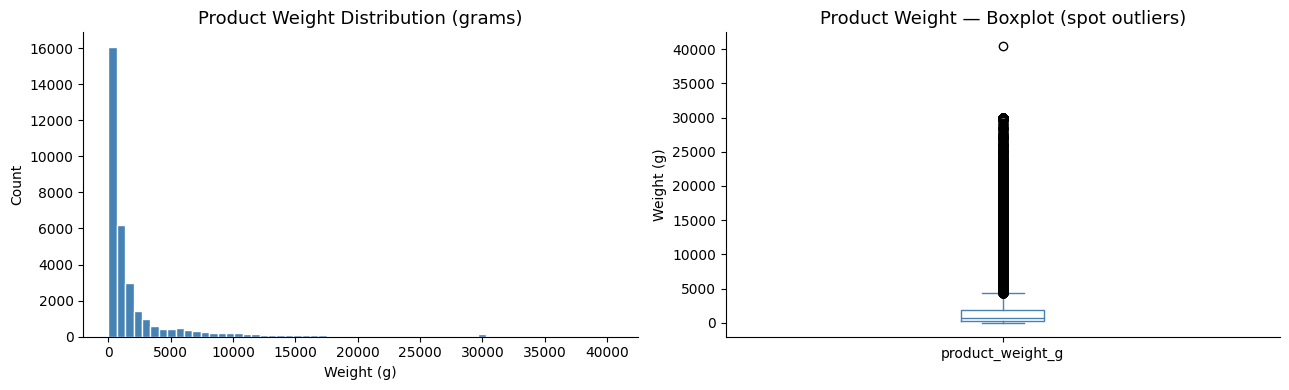

Chart saved to outputs/


In [10]:
# Visualize weight outliers
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df_products['product_weight_g'].dropna().plot(
    kind='hist', bins=60, ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].set_title('Product Weight Distribution (grams)', fontsize=13)
axes[0].set_xlabel('Weight (g)')
axes[0].set_ylabel('Count')

df_products['product_weight_g'].dropna().plot(
    kind='box', ax=axes[1], color='steelblue'
)
axes[1].set_title('Product Weight — Boxplot (spot outliers)', fontsize=13)
axes[1].set_ylabel('Weight (g)')

plt.tight_layout()
plt.savefig('../outputs/product_weight_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved to outputs/')

## 6. Deep Dive — Reviews Table

In [11]:
print('Reviews table — first 5 rows:')
df_reviews.head()

Reviews table — first 5 rows:


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


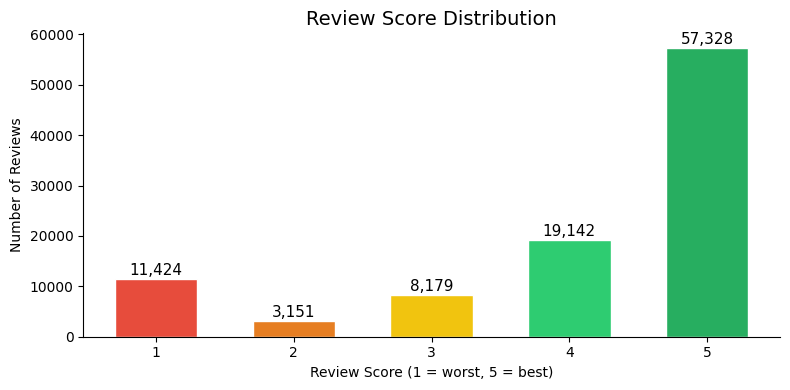


Average review score: 4.09
% of 5-star reviews : 57.8%
% of 1-star reviews : 11.5%


In [12]:
# Review score distribution
score_counts = df_reviews['review_score'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']
bars = ax.bar(score_counts.index, score_counts.values, color=colors, edgecolor='white', width=0.6)

for bar, val in zip(bars, score_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{val:,}', ha='center', va='bottom', fontsize=11)

ax.set_title('Review Score Distribution', fontsize=14)
ax.set_xlabel('Review Score (1 = worst, 5 = best)')
ax.set_ylabel('Number of Reviews')
ax.set_xticks([1, 2, 3, 4, 5])
plt.tight_layout()
plt.savefig('../outputs/review_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nAverage review score: {df_reviews['review_score'].mean():.2f}")
print(f"% of 5-star reviews : {(score_counts[5]/score_counts.sum()*100):.1f}%")
print(f"% of 1-star reviews : {(score_counts[1]/score_counts.sum()*100):.1f}%")

## 7. Deep Dive — Payments Table

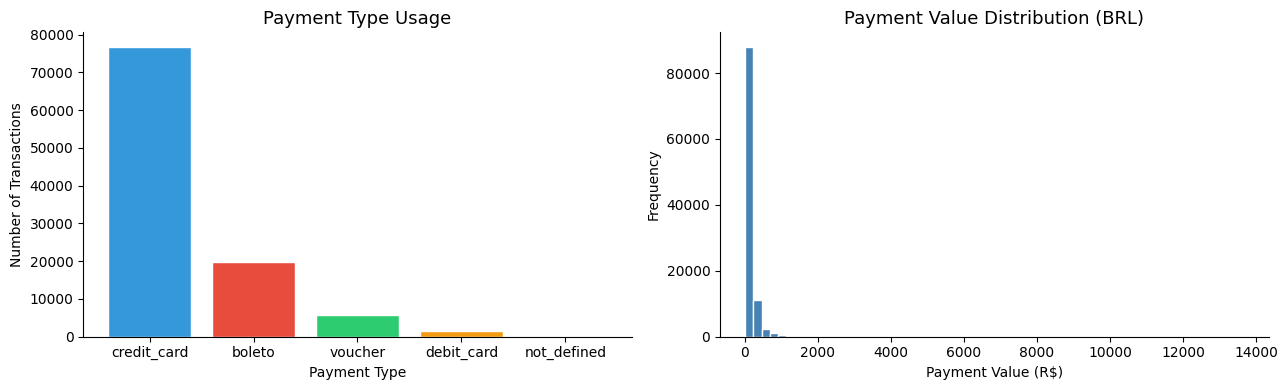

Payment value statistics:
count   103886.00
mean       154.10
std        217.49
min          0.00
25%         56.79
50%        100.00
75%        171.84
max      13664.08
Name: payment_value, dtype: float64


In [13]:
# Payment type distribution
pay_counts = df_payments['payment_type'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Bar chart
axes[0].bar(pay_counts.index, pay_counts.values,
            color=['#3498db','#e74c3c','#2ecc71','#f39c12'], edgecolor='white')
axes[0].set_title('Payment Type Usage', fontsize=13)
axes[0].set_xlabel('Payment Type')
axes[0].set_ylabel('Number of Transactions')

# Payment value distribution
df_payments['payment_value'].plot(
    kind='hist', bins=60, ax=axes[1], color='steelblue', edgecolor='white'
)
axes[1].set_title('Payment Value Distribution (BRL)', fontsize=13)
axes[1].set_xlabel('Payment Value (R$)')

plt.tight_layout()
plt.savefig('../outputs/payment_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print('Payment value statistics:')
print(df_payments['payment_value'].describe().round(2))

In [14]:
# Installments check
print('Installment counts:')
print(df_payments['payment_installments'].value_counts().head(10))

# Flag suspicious: 0 installments
zero_inst = df_payments[df_payments['payment_installments'] == 0]
print(f"\nOrders with 0 installments (suspicious): {len(zero_inst):,}")

Installment counts:
payment_installments
1     52546
2     12413
3     10461
4      7098
10     5328
5      5239
8      4268
6      3920
7      1626
9       644
Name: count, dtype: int64

Orders with 0 installments (suspicious): 2


## 8. Overall Null Heatmap — All Tables at Once

In [15]:
# Build a summary null % table across all datasets
null_summary = []
for name, df in datasets.items():
    null_pct = df.isnull().mean() * 100
    for col, pct in null_pct.items():
        if pct > 0:
            null_summary.append({'table': name, 'column': col, 'null_%': round(pct, 1)})

null_df = pd.DataFrame(null_summary).sort_values('null_%', ascending=False)
print('All columns with missing values across all tables:')
print(null_df.to_string(index=False))

All columns with missing values across all tables:
   table                        column  null_%
 reviews          review_comment_title   88.30
 reviews        review_comment_message   58.70
  orders order_delivered_customer_date    3.00
products           product_name_lenght    1.90
products         product_category_name    1.90
products    product_description_lenght    1.90
products            product_photos_qty    1.90
  orders  order_delivered_carrier_date    1.80
  orders             order_approved_at    0.20
products             product_length_cm    0.00
products              product_weight_g    0.00
products              product_width_cm    0.00
products             product_height_cm    0.00


## 9. Merge All Tables → Master Dataframe

In [16]:
# Step 1 — Aggregate payments per order (one row per order)
pay_agg = df_payments.groupby('order_id').agg(
    total_payment    = ('payment_value', 'sum'),
    payment_type     = ('payment_type', lambda x: x.mode()[0]),
    max_installments = ('payment_installments', 'max')
).reset_index()

print(f'Payments aggregated: {pay_agg.shape}')

Payments aggregated: (99440, 4)


In [17]:
# Step 2 — Aggregate reviews per order (avg score)
rev_agg = df_reviews.groupby('order_id').agg(
    review_score = ('review_score', 'mean')
).reset_index()

print(f'Reviews aggregated: {rev_agg.shape}')

Reviews aggregated: (98673, 2)


In [18]:
# Step 3 — Add English category names to products
df_products_eng = df_products.merge(
    df_translation, on='product_category_name', how='left'
)
print(f'Products with English names: {df_products_eng.shape}')

Products with English names: (32951, 10)


In [19]:
# Step 4 — Build master dataframe
master = (
    df_orders
    .merge(df_customers,    on='customer_id',  how='left')
    .merge(df_items,        on='order_id',     how='left')
    .merge(df_products_eng, on='product_id',   how='left')
    .merge(df_sellers,      on='seller_id',    how='left')
    .merge(pay_agg,         on='order_id',     how='left')
    .merge(rev_agg,         on='order_id',     how='left')
)

print(f'Master dataframe shape: {master.shape}')
print(f'Columns: {list(master.columns)}')

Master dataframe shape: (113425, 34)
Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'product_category_name_english', 'seller_zip_code_prefix', 'seller_city', 'seller_state', 'total_payment', 'payment_type', 'max_installments', 'review_score']


## 10. Feature Engineering — Add Calculated Columns

In [20]:
# Convert timestamps in master
for col in date_cols:
    master[col] = pd.to_datetime(master[col])

# Profit proxy = price minus freight
# NOTE: Olist does not provide cost-of-goods data.
# This is an approximation — always disclose this assumption in analysis.
master['profit_proxy'] = master['price'] - master['freight_value']

# Delivery delay = actual delivery minus estimated delivery (in days)
# Positive = late, Negative = early
master['delivery_delay_days'] = (
    master['order_delivered_customer_date'] -
    master['order_estimated_delivery_date']
).dt.days

# Actual delivery time = purchase to delivered (in days)
master['actual_delivery_days'] = (
    master['order_delivered_customer_date'] -
    master['order_purchase_timestamp']
).dt.days

# Late flag
master['is_late'] = (master['delivery_delay_days'] > 0).astype(int)

# Month and year columns for time series
master['order_month']  = master['order_purchase_timestamp'].dt.to_period('M')
master['order_year']   = master['order_purchase_timestamp'].dt.year
master['order_dow']    = master['order_purchase_timestamp'].dt.day_name()

# Freight ratio = freight / price
master['freight_ratio'] = (
    master['freight_value'] / master['price'].replace(0, np.nan)
).round(4)

print('New columns added:')
new_cols = ['profit_proxy', 'delivery_delay_days', 'actual_delivery_days',
            'is_late', 'order_month', 'order_year', 'order_dow', 'freight_ratio']
print(master[new_cols].describe().round(2))

New columns added:
       profit_proxy  delivery_delay_days  actual_delivery_days   is_late  \
count     112650.00            110196.00             110196.00 113425.00   
mean         100.66               -12.03                 12.01      0.06   
std          177.67                10.16                  9.45      0.24   
min         -140.53              -147.00                  0.00      0.00   
25%           24.52               -17.00                  6.00      0.00   
50%           56.29               -13.00                 10.00      0.00   
75%          111.83                -7.00                 15.00      0.00   
max         6540.69               188.00                209.00      1.00   

       order_year  freight_ratio  
count   113425.00      112650.00  
mean      2017.54           0.32  
std          0.51           0.35  
min       2016.00           0.00  
25%       2017.00           0.13  
50%       2018.00           0.23  
75%       2018.00           0.39  
max       2018.0

## 11. Final Data Quality Check on Master

In [21]:
print('Master dataframe — final shape:', master.shape)
print()

null_master = master.isnull().sum()
null_master = null_master[null_master > 0].sort_values(ascending=False)
null_pct_master = (null_master / len(master) * 100).round(1)

print('Remaining nulls in master:')
for col in null_master.index:
    print(f'  {col:<45} {null_master[col]:>7,}  ({null_pct_master[col]}%)')

Master dataframe — final shape: (113425, 42)

Remaining nulls in master:
  order_delivered_customer_date                   3,229  (2.8%)
  actual_delivery_days                            3,229  (2.8%)
  delivery_delay_days                             3,229  (2.8%)
  product_category_name_english                   2,402  (2.1%)
  product_category_name                           2,378  (2.1%)
  product_description_lenght                      2,378  (2.1%)
  product_name_lenght                             2,378  (2.1%)
  product_photos_qty                              2,378  (2.1%)
  order_delivered_carrier_date                    1,968  (1.7%)
  review_score                                      961  (0.8%)
  product_height_cm                                 793  (0.7%)
  product_weight_g                                  793  (0.7%)
  product_width_cm                                  793  (0.7%)
  product_length_cm                                 793  (0.7%)
  seller_state                 

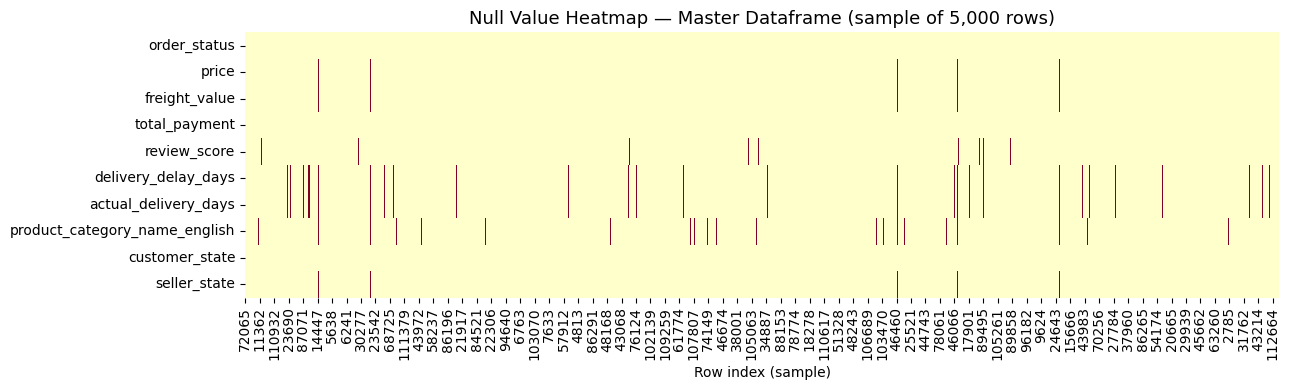

Chart saved to outputs/


In [22]:
# Null heatmap on master (sample for readability)
sample_cols = [
    'order_status', 'price', 'freight_value', 'total_payment',
    'review_score', 'delivery_delay_days', 'actual_delivery_days',
    'product_category_name_english', 'customer_state', 'seller_state'
]

null_matrix = master[sample_cols].isnull()

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(
    null_matrix.sample(min(5000, len(master)), random_state=42).T,
    cbar=False, cmap='YlOrRd', ax=ax,
    yticklabels=sample_cols
)
ax.set_title('Null Value Heatmap — Master Dataframe (sample of 5,000 rows)', fontsize=13)
ax.set_xlabel('Row index (sample)')
plt.tight_layout()
plt.savefig('../outputs/null_heatmap_master.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved to outputs/')

## 12. Save Clean Master Dataframe

In [23]:
# Save master to data folder so other notebooks can load it
master.to_csv(DATA_PATH + 'master_olist.csv', index=False)

print('master_olist.csv saved successfully!')
print(f'  Rows    : {master.shape[0]:,}')
print(f'  Columns : {master.shape[1]}')
print()
print('Ready to load in next notebook:')
print("  master = pd.read_csv('../data/master_olist.csv')")

master_olist.csv saved successfully!
  Rows    : 113,425
  Columns : 42

Ready to load in next notebook:
  master = pd.read_csv('../data/master_olist.csv')


## 13. Data Quality Summary — Issues Found & Decisions Made

| # | Issue Found | Impact | Decision |
|---|---|---|---|
| 1 | `order_delivered_customer_date` has ~2,965 nulls | Undelivered / cancelled orders | Keep rows; exclude from delivery analysis |
| 2 | `order_approved_at` has ~160 nulls | Payment not approved | Keep rows; flag as pending |
| 3 | Product dimensions have ~2.4% nulls | Affects freight modelling | Keep; fill with median per category |
| 4 | `product_category_name` has ~1.2% nulls | Missing category labels | Labelled as 'unknown' |
| 5 | `review_score` nulls in master | Orders with no review | Expected; excluded from review analysis |
| 6 | `payment_installments = 0` found | Possibly free/voucher orders | Kept; flagged for investigation |
| 7 | Some products have extreme weights (>30kg) | Valid heavy items (furniture) | Kept; treated as valid outliers |
| 8 | Geolocation has many duplicate zip codes | Multiple coords per zip | Not merged — used for mapping only |

---

## Next Step → Notebook 02: Exploratory Data Analysis (EDA)

The `master_olist.csv` file is now ready. Open `02_EDA_analysis.ipynb` and load it with:
```python
master = pd.read_csv('../data/master_olist.csv')
```

In [24]:
# ============================================================
# BONUS: Load all tables into SQLite database
# ============================================================
import sqlite3
import os

DB_PATH = DATA_PATH + 'olist.db'

print('Creating SQLite database...')
conn = sqlite3.connect(DB_PATH)

# df_products_eng already created earlier in this notebook
# (products merged with translation)
tables = {
    'orders'      : df_orders,
    'order_items' : df_items,
    'customers'   : df_customers,
    'products'    : df_products_eng,   # English category names
    'sellers'     : df_sellers,
    'reviews'     : df_reviews,
    'payments'    : df_payments
}

for name, df in tables.items():
    df.to_sql(name, conn, if_exists='replace', index=False)
    print(f'  Loaded: {name:<15} {len(df):>8,} rows')

print(f'\nDatabase saved at: {os.path.abspath(DB_PATH)}')
print('olist.db is ready for SQL queries!')

Creating SQLite database...
  Loaded: orders            99,441 rows
  Loaded: order_items      112,650 rows
  Loaded: customers         99,441 rows
  Loaded: products          32,951 rows
  Loaded: sellers            3,095 rows
  Loaded: reviews           99,224 rows
  Loaded: payments         103,886 rows

Database saved at: /workspaces/Decision-Intelligence-System-for-E-commerce-Profit-Customer-Insights/olist-ecommerce-analysis/data/olist.db
olist.db is ready for SQL queries!


In [25]:
import glob

sql_files = sorted(glob.glob('../sql/*.sql'))
print(f'Found {len(sql_files)} SQL files\n')

for filepath in sql_files:
    filename = os.path.basename(filepath)
    print(f'{"="*50}')
    print(f'  Running: {filename}')
    print(f'{"="*50}')

    with open(filepath) as f:
        query = f.read()

    try:
        result = pd.read_sql_query(query, conn)
        print(result.head(8).to_string(index=False))
        print(f'\n  → {len(result)} rows total')

        # Save result to outputs/
        out_name = filename.replace('.sql', '_result.csv')
        result.to_csv(f'../outputs/{out_name}', index=False)
        print(f'  → Saved: outputs/{out_name}')
    except Exception as e:
        print(f'  ERROR: {e}')
    print()

conn.close()
print('All queries complete! Results saved to outputs/')

Found 10 SQL files

  Running: 01_revenue_by_category.sql
             category  total_orders  total_revenue  total_freight  profit_proxy  avg_price  avg_freight  freight_pct_of_revenue  avg_review_score
        watches_gifts          5495     1167246.63       98306.28    1068940.35     198.88        16.75                    8.40              4.07
        health_beauty          8647     1237439.95      179829.04    1057610.91     130.00        18.89                   14.50              4.19
       bed_bath_table          9272     1037177.69      204312.09     832865.60      93.38        18.39                   19.70              3.92
       sports_leisure          7530      960189.09      164448.34     795740.75     113.11        19.37                   17.10              4.17
computers_accessories          6530      896243.28      145070.99     751172.29     116.27        18.82                   16.20              3.98
      furniture_decor          6307      718344.78      170012.29 